In [2]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
from google.colab import files

# Load Excel file
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')
payments = pd.read_csv('payments.csv')
products = pd.read_csv('products.csv')
sellers = pd.read_csv('sellers.csv')
geolocation = pd.read_csv('geolocation.csv')


## Preview the Data

In [4]:
customers.head()      # First 5 rows of customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
orders.head()         # First 5 rows of orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 0:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 3:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 0:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 8:38:49,2018-08-08 8:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 0:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 0:28:42,2017-12-15 0:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 0:00:00


In [6]:
order_items.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 9:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
payments.head()


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [8]:
products.head()


,product_id,product category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,Art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sport leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,babies,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [9]:
sellers.head()


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [10]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


## Data Cleaning

In [11]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [12]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [13]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [14]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [15]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [16]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product category            32341 non-null  object 
 2   product_name_length         32341 non-null  float64
 3   product_description_length  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [17]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [18]:
# Check missing values
print(customers.isnull().sum())


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [19]:
print(orders.isnull().sum())


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [20]:
print(order_items.isnull().sum())


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [21]:
print(payments.isnull().sum())


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [22]:
print(products.isnull().sum())


product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [23]:
print(sellers.isnull().sum())


seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


In [24]:
print(geolocation.isnull().sum())

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


Filling misisng Data

In [25]:
# Order Dataset
orders['order_approved_at'] = orders['order_approved_at'].fillna(orders['order_purchase_timestamp'])

# Leave delivery dates as NaT (we may want to ignore incomplete orders in some analysis)
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'], errors='coerce')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')

In [26]:
# Product Dataset
# Fill missing category with 'Unknown'
products['product category'] = products['product category'].fillna('Unknown')

# Fill missing lengths/descriptions/photos with 0
products['product_name_length'] = products['product_name_length'].fillna(0)
products['product_description_length'] = products['product_description_length'].fillna(0)
products['product_photos_qty'] = products['product_photos_qty'].fillna(0)

# Fill small numeric gaps with median
products['product_weight_g'] = products['product_weight_g'].fillna(products['product_weight_g'].median())
products['product_length_cm'] = products['product_length_cm'].fillna(products['product_length_cm'].median())
products['product_height_cm'] = products['product_height_cm'].fillna(products['product_height_cm'].median())
products['product_width_cm'] = products['product_width_cm'].fillna(products['product_width_cm'].median())

In [27]:
print(orders.isnull().sum())
print(products.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
product_id                    0
product category              0
product_name_length           0
product_description_length    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


Let check for duplicate

In [28]:
# Customers
print("Customers duplicates:", customers.duplicated().sum())

Customers duplicates: 0


In [29]:
# Orders
print("Orders duplicates:", orders.duplicated().sum())

Orders duplicates: 0


In [30]:
# Order Items
print("Order Items duplicates:", order_items.duplicated().sum())

Order Items duplicates: 0


In [31]:
# Payments
print("Payments duplicates:", payments.duplicated().sum())

Payments duplicates: 0


In [32]:
# Payments
print("Payments duplicates:", payments.duplicated().sum())

Payments duplicates: 0


In [33]:
# Products
print("Products duplicates:", products.duplicated().sum())

Products duplicates: 0


In [34]:
# Sellers
print("Sellers duplicates:", sellers.duplicated().sum())



Sellers duplicates: 0


In [35]:
# Geolocation
print("Geolocation duplicates:", geolocation.duplicated().sum())

Geolocation duplicates: 261831


In [36]:
# Check the locations uniques
geolocation_duplicates = geolocation[geolocation.duplicated(subset=['geolocation_zip_code_prefix','geolocation_city','geolocation_state'], keep=False)]
geolocation_duplicates.head(10)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
5,1012,-23.547762,-46.635361,são paulo,SP
6,1047,-23.546273,-46.641225,sao paulo,SP
7,1013,-23.546923,-46.634264,sao paulo,SP
8,1029,-23.543769,-46.634278,sao paulo,SP
9,1011,-23.547640,-46.636032,sao paulo,SP


In [37]:
#fixing the data types
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')

BASIC PROBLEMS

1. Unique Cities

In [38]:
unique_cities = customers['customer_city'].unique()
print(f"Total Unique Cities: {len(unique_cities)}")

Total Unique Cities: 4119


2. Orders in 2017

In [39]:
orders_2017 = orders[orders['order_purchase_timestamp'].dt.year == 2017].shape[0]
print(f"Orders placed in 2017: {orders_2017}")

Orders placed in 2017: 45101


3. Total sales per category

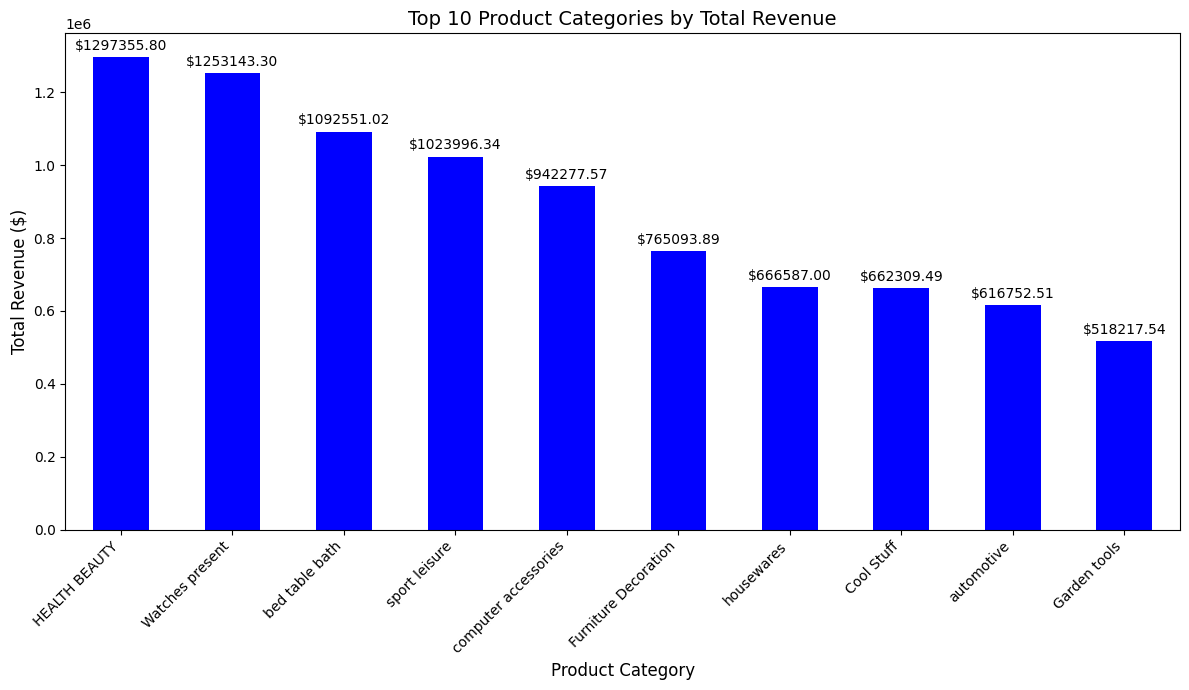

In [40]:
df = pd.merge(products, order_items, on='product_id')
df = pd.merge(df, payments, on='order_id')
top_revenue_cat = df.groupby('product category')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
ax = top_revenue_cat.plot(kind='bar', color='blue')
ax.bar_label(ax.containers[0], fmt='$%.2f', padding=3)
plt.title('Top 10 Product Categories by Total Revenue', fontsize=14)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

4. Percentage of orders paid in installments

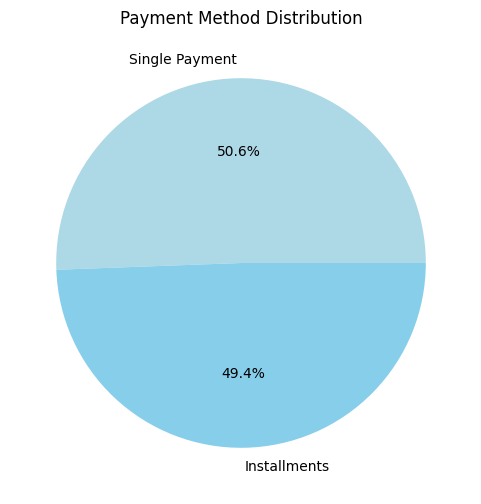

In [41]:
inst_count = payments['payment_installments'].apply(lambda x: 'Installments' if x > 1 else 'Single Payment').value_counts()
plt.figure(figsize=(6, 6))
inst_count.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'skyblue'])
plt.title('Payment Method Distribution')
plt.ylabel('')
plt.show()

5. Customers per state

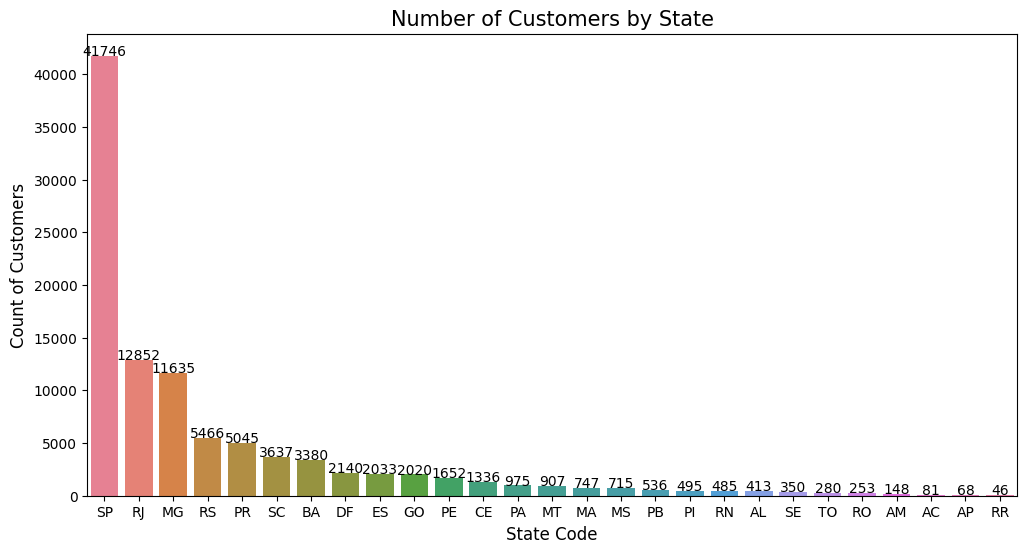

In [42]:
state_counts = customers['customer_state'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=state_counts.index, y=state_counts.values, hue=state_counts.index, legend=False)

plt.title('Number of Customers by State', fontsize=15)
plt.xlabel('State Code', fontsize=12)
plt.ylabel('Count of Customers', fontsize=12)

for i, value in enumerate(state_counts.values):
    plt.text(i, value + 50, str(value), ha='center', fontsize=10)

plt.show()

INTERMEDIATE QUESTIONS

1. Orders per month in 2018

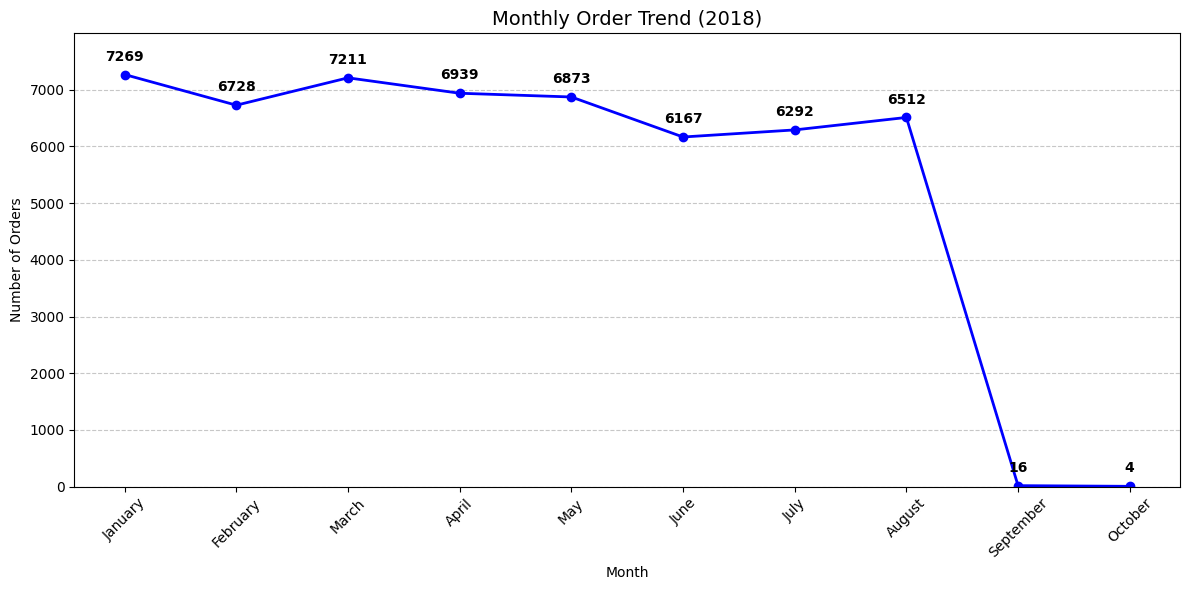

In [43]:
orders_2018 = orders[orders['order_purchase_timestamp'].dt.year == 2018].copy()

orders_2018['month_name'] = orders_2018['order_purchase_timestamp'].dt.strftime('%B')
orders_2018['month_num'] = orders_2018['order_purchase_timestamp'].dt.month

monthly_orders = orders_2018.groupby(['month_num', 'month_name']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
plt.plot(monthly_orders['month_name'], monthly_orders['count'], marker='o', color='blue', linewidth=2)

for i, txt in enumerate(monthly_orders['count']):
    plt.annotate(f'{txt}', (monthly_orders['month_name'][i], monthly_orders['count'][i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

plt.title('Monthly Order Trend (2018)', fontsize=14)
plt.ylabel('Number of Orders')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, monthly_orders['count'].max() * 1.1)
plt.tight_layout()
plt.show()

2. Avg Products per Order by City

/tmp/ipykernel_19010/364235734.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  city_stats = df_city.groupby('customer_city').apply(


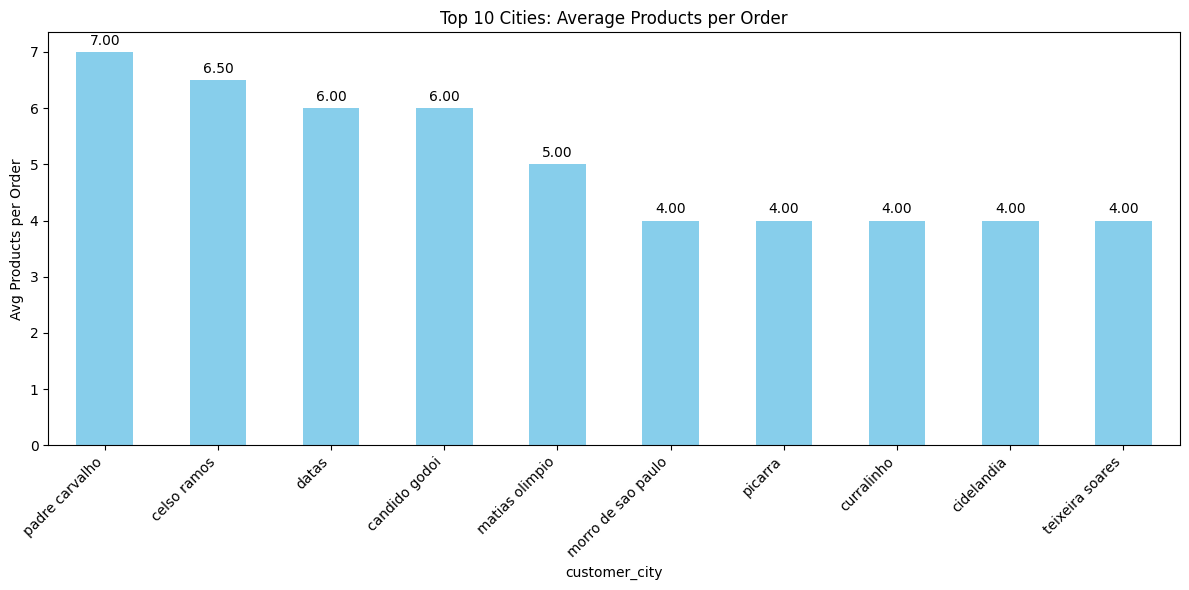

In [44]:
df_city = pd.merge(customers, orders, on='customer_id')
df_city = pd.merge(df_city, order_items, on='order_id')

city_stats = df_city.groupby('customer_city').apply(
    lambda x: x['product_id'].count() / x['order_id'].nunique()
).sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = city_stats.plot(kind='bar', color='skyblue')

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.title('Top 10 Cities: Average Products per Order')
plt.ylabel('Avg Products per Order')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

3. Percentage Revenue per Category

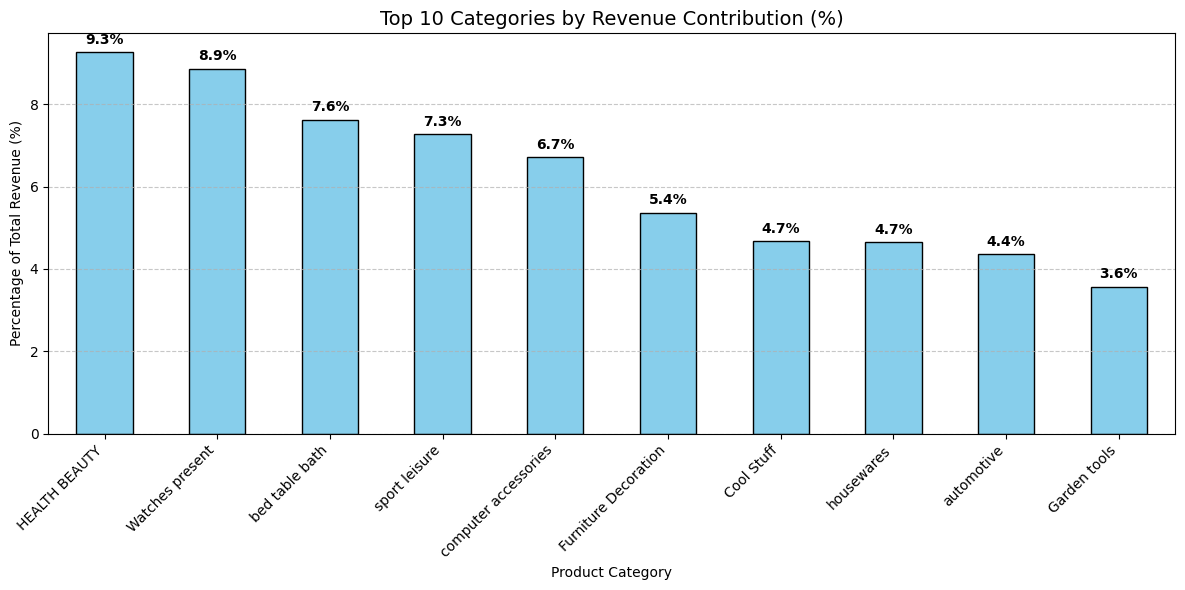

In [45]:
rev_per_cat = pd.merge(order_items[['product_id', 'price']],
                       products[['product_id', 'product category']], on='product_id')

total_revenue = rev_per_cat['price'].sum()
category_revenue = rev_per_cat.groupby('product category')['price'].sum()

cat_rev_pct = (category_revenue / total_revenue) * 100
cat_rev_pct = cat_rev_pct.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = cat_rev_pct.plot(kind='bar', color='skyblue', edgecolor='black')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.title('Top 10 Categories by Revenue Contribution (%)', fontsize=14)
plt.ylabel('Percentage of Total Revenue (%)')
plt.xlabel('Product Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

4. Correlation between Price and Popularity

In [75]:
product_stats = (
    order_items[['product_id', 'price']]
    .groupby('product_id')
    .agg(
        purchase_count=('product_id', 'size'),
        mean_price=('price', 'mean')
    )
    .reset_index()
)

In [76]:
product_stats = product_stats.sort_values('purchase_count', ascending=False).head(10)

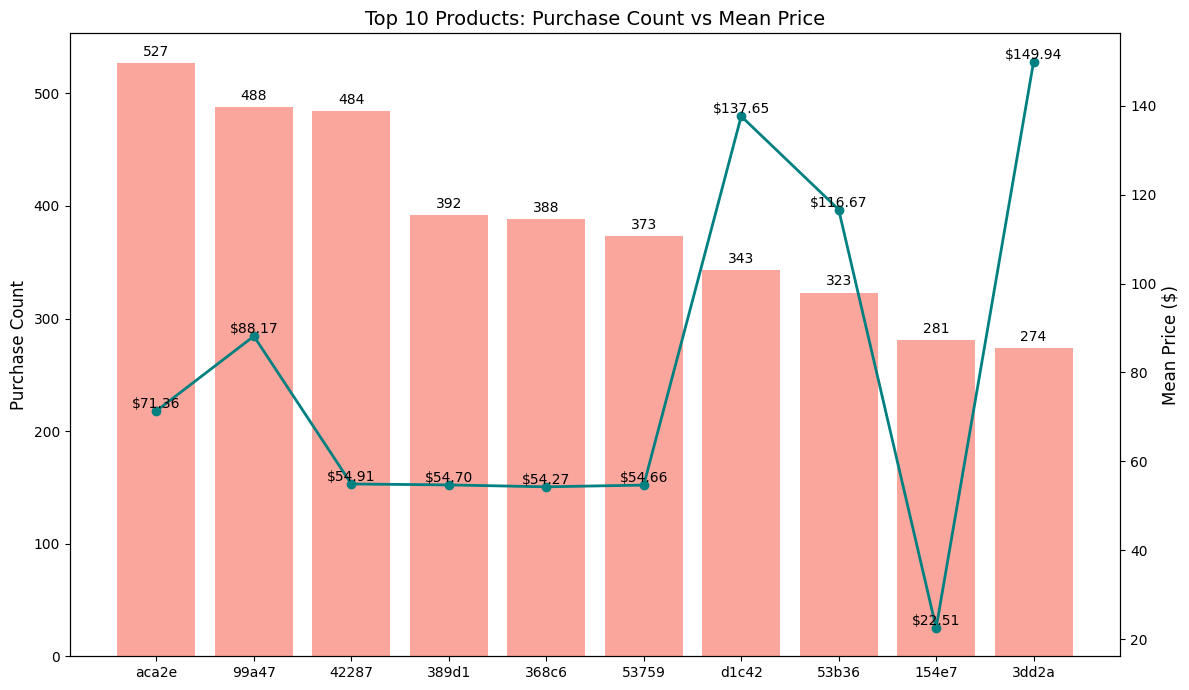

In [78]:
plot_df = product_stats.copy()

plot_df['label'] = plot_df['product_id'].astype(str).str[:5]

fig, ax1 = plt.subplots(figsize=(12, 7))

bars = ax1.bar(plot_df['label'], plot_df['purchase_count'], color='salmon', alpha=0.7)
ax1.set_ylabel('Purchase Count', fontsize=12)

ax1.bar_label(bars, padding=3)

ax2 = ax1.twinx()
ax2.plot(plot_df['label'], plot_df['mean_price'], color='teal', marker='o', linewidth=2)
ax2.set_ylabel('Mean Price ($)', fontsize=12)

for i in range(len(plot_df)):
    ax2.text(
        plot_df['label'].iloc[i],
        plot_df['mean_price'].iloc[i],
        f"${plot_df['mean_price'].iloc[i]:.2f}",
        ha='center',
        va='bottom'
    )

plt.title('Top 10 Products: Purchase Count vs Mean Price', fontsize=14)
plt.tight_layout()
plt.show()

5. Seller Revenue Ranking (Top 10)

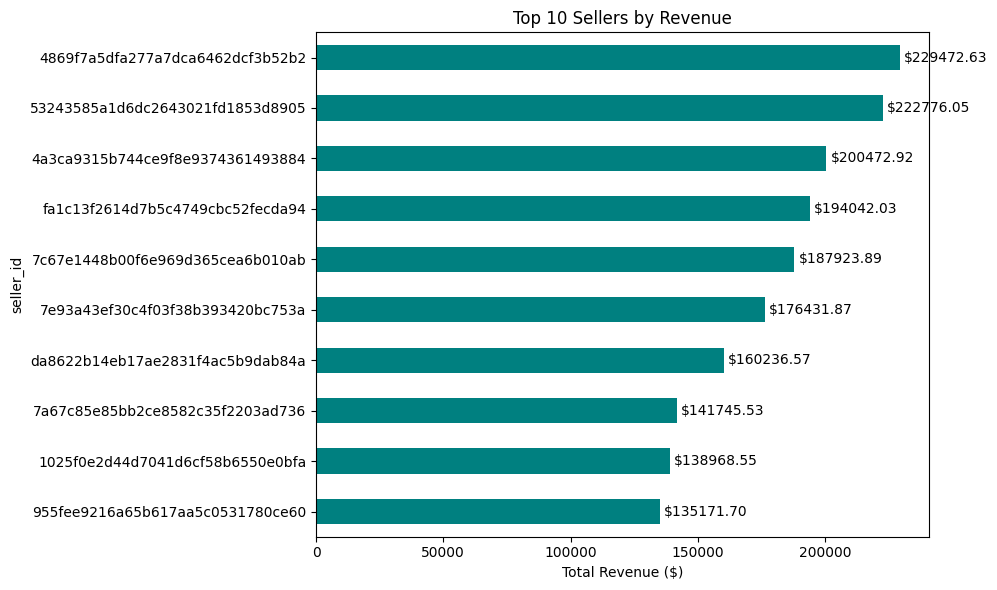

In [57]:
seller_rev = order_items.groupby('seller_id')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = seller_rev.plot(kind='barh', color='teal')

ax.bar_label(ax.containers[0], fmt='$%.2f', padding=3)

plt.title('Top 10 Sellers by Revenue')
plt.xlabel('Total Revenue ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

ADVANCED QUESTIONS

1. Moving Average of Order Values

In [58]:
orders.rename(columns={orders.columns[0]: 'order_id'}, inplace=True)

print(orders.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')


In [59]:
df = pd.merge(orders, payments, on='order_id')

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df = df.sort_values(['customer_id', 'order_purchase_timestamp'])

df['moving_avg'] = (df.groupby('customer_id')['payment_value']
                    .expanding()
                    .mean()
                    .reset_index(level=0, drop=True))

result = df[['moving_avg']]
print(result.head(10))

       moving_avg
71587      114.74
10466       67.41
68795      195.42
45159      179.35
6119       107.01
76895       71.80
48295       49.40
62657      166.59
82776       85.23
83947     1255.71


2. Cumulative sales per month for each year

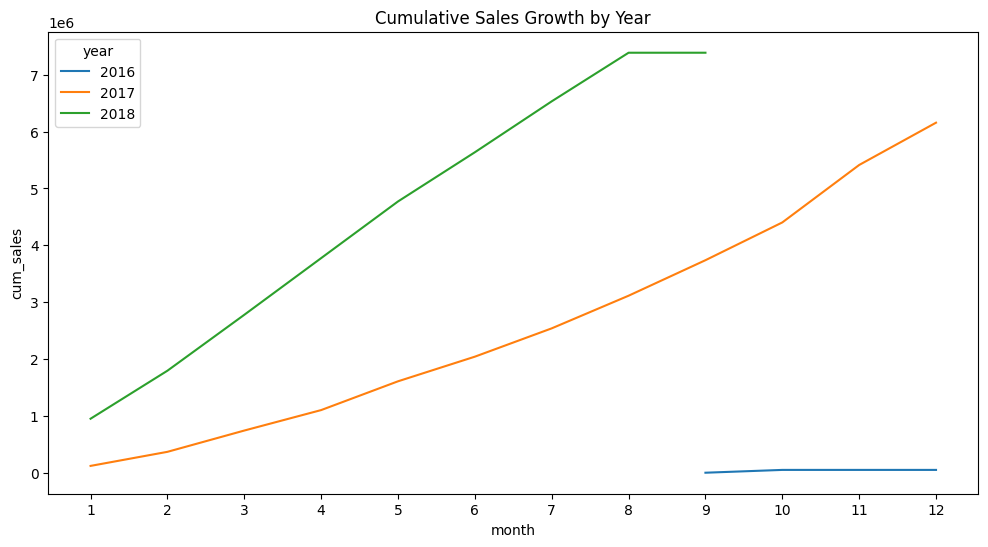

In [60]:
order_val = order_items.groupby('order_id')['price'].sum().reset_index()
sales_trend = pd.merge(orders[['order_id', 'order_purchase_timestamp']], order_val, on='order_id')
sales_trend['year'] = sales_trend['order_purchase_timestamp'].dt.year
sales_trend['month'] = sales_trend['order_purchase_timestamp'].dt.month
monthly_sales = sales_trend.groupby(['year', 'month'])['price'].sum().reset_index()
monthly_sales['cum_sales'] = monthly_sales.groupby('year')['price'].cumsum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='month', y='cum_sales', hue='year', palette='tab10')
plt.title('Cumulative Sales Growth by Year')
plt.xticks(range(1, 13))
plt.show()

3. Year-over-Year (YoY) Growth

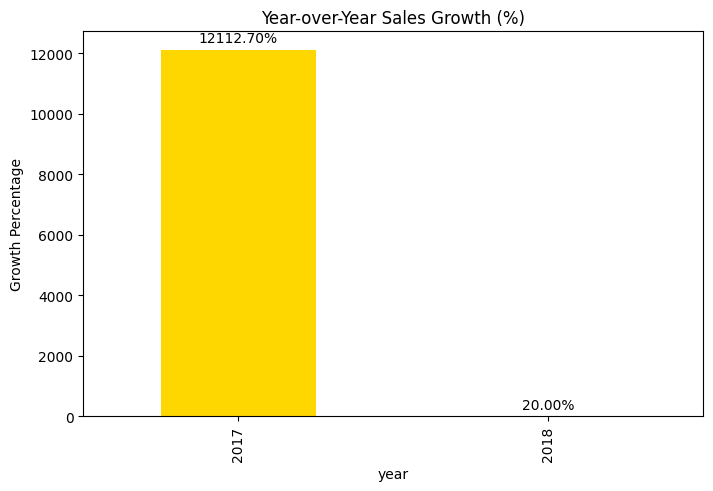

In [73]:
df4 = pd.merge(orders, payments, on='order_id')

df4['year'] = pd.to_datetime(df4['order_purchase_timestamp']).dt.year
yearly_sales = df4.groupby('year')['payment_value'].sum()

yoy_growth = yearly_sales.pct_change() * 100

ax = yoy_growth.dropna().plot(kind='bar', figsize=(8, 5), color='gold')
ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3)
plt.title('Year-over-Year Sales Growth (%)')
plt.ylabel('Growth Percentage')
plt.show()

4. Retention Rate

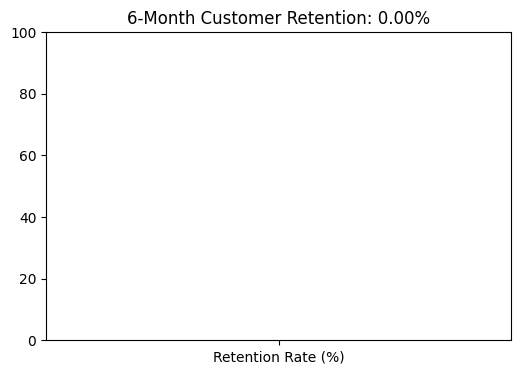

In [61]:
first_purchase = orders.groupby('customer_id')['order_purchase_timestamp'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_order_date']

retention_data = pd.merge(orders[['customer_id', 'order_purchase_timestamp']], first_purchase, on='customer_id')

retention_data['days_diff'] = (retention_data['order_purchase_timestamp'] - retention_data['first_order_date']).dt.days

retained_customers = retention_data[(retention_data['days_diff'] > 0) & (retention_data['days_diff'] <= 180)]['customer_id'].nunique()
total_unique_customers = customers['customer_id'].nunique()

retention_rate = (retained_customers / total_unique_customers) * 100

plt.figure(figsize=(6, 4))
plt.bar(['Retention Rate (%)'], [retention_rate], color='seagreen')
plt.ylim(0, 100)
plt.title(f'6-Month Customer Retention: {retention_rate:.2f}%')
plt.show()

5. Top 3 Customers who spent the most money per year

In [69]:
top_customers = (
    orders.merge(payments, on='order_id', how='left')
    .groupby(['year', 'customer_id'], as_index=False)['payment_value']
    .sum()
)

top_3_per_year = (
    top_customers
    .sort_values(['year', 'payment_value'], ascending=[True, False])
    .groupby('year')
    .head(3)
)

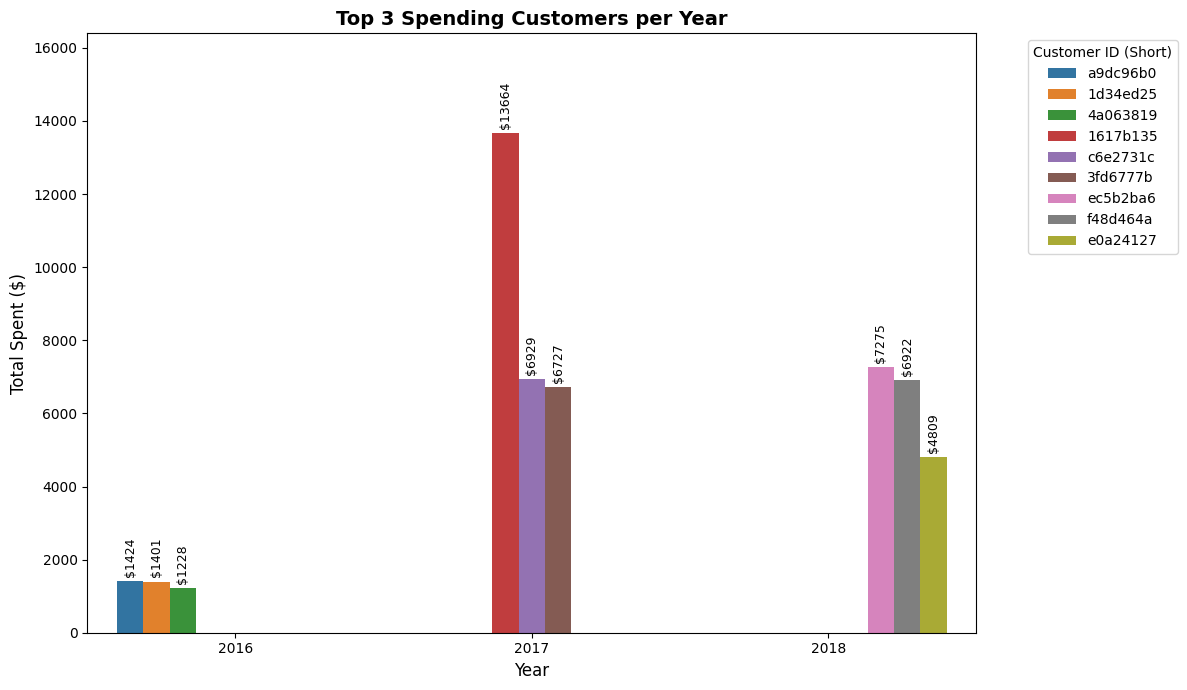

In [72]:
top_3_per_year['cust_label'] = top_3_per_year['customer_id'].astype(str).str[:8]

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=top_3_per_year, x='year', y='payment_value', hue='cust_label')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3, fontsize=9, rotation=90)

plt.title('Top 3 Spending Customers per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Spent ($)', fontsize=12)

plt.margins(y=0.2)

plt.legend(title='Customer ID (Short)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()